In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [2]:
cwd = Path.cwd()

if cwd.name == "Notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "Data"
FLIGHT_PATH = DATA_DIR / "Detailed_Statistics_Departures.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Flight path:", FLIGHT_PATH)

if not FLIGHT_PATH.exists():
    raise FileNotFoundError(f"Flight file not found: {FLIGHT_PATH}")

Project root: f:\6600_ML\6600-Group3-ML
Data directory: f:\6600_ML\6600-Group3-ML\Data
Flight path: f:\6600_ML\6600-Group3-ML\Data\Detailed_Statistics_Departures.csv


In [3]:
df = pd.read_csv(FLIGHT_PATH, low_memory=False)
df.columns = [str(c).strip() for c in df.columns]

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nFirst 20 columns:")
print(df.columns.tolist()[:20])

df.head()

Rows: 1048572
Columns: 17

First 20 columns:
['Carrier Code', 'Date (MM/DD/YYYY)', 'Flight Number', 'Tail Number', 'Destination Airport', 'Scheduled departure time', 'Actual departure time', 'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)', 'Departure delay (Minutes)', 'Wheels-off time', 'Taxi-Out time (Minutes)', 'Delay Carrier (Minutes)', 'Delay Weather (Minutes)', 'Delay National Aviation System (Minutes)', 'Delay Security (Minutes)', 'Delay Late Aircraft Arrival (Minutes)']


,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,AS,1/1/2016,15,N552AS,SEA,18:45,19:10,400,373,25,19:26,16,0,0,0,0,0
1,AS,1/1/2016,25,N492AS,SEA,7:00,7:03,405,371,3,7:25,22,0,0,0,0,0
2,AS,1/1/2016,33,N549AS,PDX,17:10,17:20,399,332,10,17:32,12,0,0,0,0,0
3,AS,1/1/2016,769,N526AS,SAN,18:15,18:12,419,370,-3,18:31,19,0,0,0,0,0
4,AS,1/1/2017,15,N568AS,SEA,18:50,21:40,400,384,170,22:08,28,36,0,0,0,118


In [4]:
date_col = "Date (MM/DD/YYYY)"
time_col = "Scheduled departure time"
delay_col = "Departure delay (Minutes)"
elapsed_col = "Scheduled elapsed time (Minutes)"

df["Date"] = pd.to_datetime(df[date_col], format="%m/%d/%Y", errors="coerce")
df["Month"] = df["Date"].dt.month
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Year"] = df["Date"].dt.year

df["Season"] = np.select(
    [
        df["Month"].isin([12, 1, 2]),
        df["Month"].isin([3, 4, 5]),
        df["Month"].isin([6, 7, 8]),
        df["Month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Fall"],
    default="Unknown"
)

day_name_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}
df["Day_Name"] = df["Day_of_Week"].map(day_name_map)

sched_dt = pd.to_datetime(
    df[time_col].astype(str).str.strip(),
    format="%H:%M",
    errors="coerce"
)

df["Scheduled_Hour"] = sched_dt.dt.hour

In [5]:
def time_bucket(hour):
    if pd.isna(hour):
        return "Unknown"
    hour = int(hour)
    if 5 <= hour <= 7:
        return "Early Morning"
    elif 8 <= hour <= 11:
        return "Morning Peak"
    elif 12 <= hour <= 14:
        return "Midday"
    elif 15 <= hour <= 17:
        return "Afternoon"
    elif 18 <= hour <= 21:
        return "Evening"
    else:
        return "Late Night"

df["Time_Bucket"] = df["Scheduled_Hour"].apply(time_bucket)

In [6]:
df = df[df[delay_col].notna()].copy()
df["Delay_20"] = (df[delay_col] > 20).astype(int)

print("Target distribution:")
print(df["Delay_20"].value_counts())

print("\nTarget proportion:")
print(df["Delay_20"].value_counts(normalize=True))

Target distribution:
Delay_20
0    870234
1    178338
Name: count, dtype: int64

Target proportion:
Delay_20
0    0.829923
1    0.170077
Name: proportion, dtype: float64


In [8]:
feature_cols = [
    "Carrier Code",
    "Season",
    "Day_Name",
    "Time_Bucket",
    "Scheduled_Hour",
    elapsed_col
]

target_col = "Delay_20"

model_df = df[feature_cols + [target_col]].copy()
X = model_df[feature_cols]
y = model_df[target_col].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1048572, 6)
Target shape: (1048572,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (838857, 6) (838857,)
Test shape: (209715, 6) (209715,)


In [10]:
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Carrier Code', 'Season', 'Day_Name', 'Time_Bucket']
Numeric features: ['Scheduled_Hour', 'Scheduled elapsed time (Minutes)']


C:\Users\DigerRain\AppData\Local\Temp\ipykernel_38344\3303818132.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [12]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ))
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 3, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC AUC:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


f:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2'}

Best CV ROC AUC:
0.686


In [13]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

print(metrics_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

      Metric     Value
0   Accuracy  0.829941
1  Precision  0.700000
2     Recall  0.000196
3   F1 Score  0.000392
4    ROC AUC  0.686635

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    174047
           1       0.70      0.00      0.00     35668

    accuracy                           0.83    209715
   macro avg       0.76      0.50      0.45    209715
weighted avg       0.81      0.83      0.75    209715



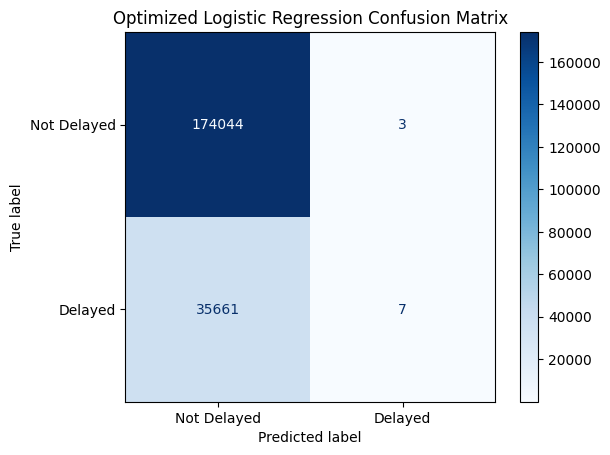

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delayed", "Delayed"]
)

disp.plot(cmap="Blues")
plt.title("Optimized Logistic Regression Confusion Matrix")
plt.show()

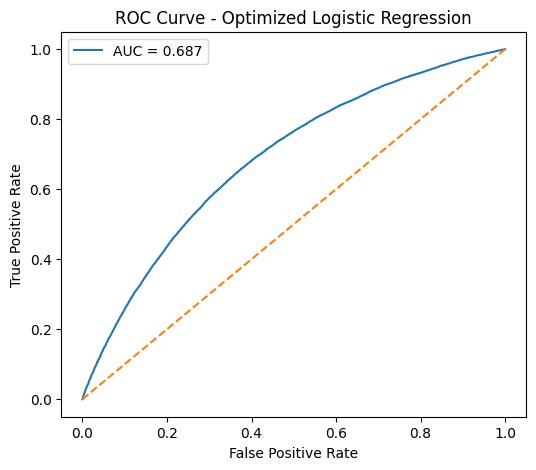

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Logistic Regression")
plt.legend()
plt.show()

In [16]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values("Absolute_Coefficient", ascending=False)

print("Top 20 Most Influential Features:")
print(coef_df.head(20))

Top 20 Most Influential Features:
                           Feature  Coefficient  Absolute_Coefficient
6             cat__Carrier Code_F9     0.602908              0.602908
3             cat__Carrier Code_AS    -0.545655              0.545655
0              num__Scheduled_Hour     0.518427              0.518427
24     cat__Time_Bucket_Late Night    -0.471710              0.471710
10                cat__Season_Fall    -0.442856              0.442856
2             cat__Carrier Code_AA    -0.382924              0.382924
22  cat__Time_Bucket_Early Morning    -0.336902              0.336902
8             cat__Carrier Code_UA    -0.335606              0.335606
20         cat__Day_Name_Wednesday    -0.312916              0.312916
13              cat__Season_Winter    -0.303550              0.303550
11              cat__Season_Spring    -0.296404              0.296404
5             cat__Carrier Code_DL    -0.246687              0.246687
19           cat__Day_Name_Tuesday    -0.240337         

In [17]:
comparison_row = pd.DataFrame({
    "Model": ["Optimized Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

print(comparison_row)

                           Model  Accuracy  Precision    Recall  F1 Score  \
0  Optimized Logistic Regression  0.829941        0.7  0.000196  0.000392   

    ROC AUC  
0  0.686635  


In [18]:
output_dir = Path.cwd()

metrics_df.to_csv(output_dir / "optimized_logistic_regression_metrics.csv", index=False)
coef_df.to_csv(output_dir / "optimized_logistic_regression_coefficients.csv", index=False)
comparison_row.to_csv(output_dir / "optimized_logistic_regression_comparison_row.csv", index=False)

print("Saved files:")
print(output_dir / "optimized_logistic_regression_metrics.csv")
print(output_dir / "optimized_logistic_regression_coefficients.csv")
print(output_dir / "optimized_logistic_regression_comparison_row.csv")

Saved files:
f:\6600_ML\6600-Group3-ML\Notebooks\optimized_logistic_regression_metrics.csv
f:\6600_ML\6600-Group3-ML\Notebooks\optimized_logistic_regression_coefficients.csv
f:\6600_ML\6600-Group3-ML\Notebooks\optimized_logistic_regression_comparison_row.csv
